# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 04     |  |
| :-------------|:-------------|
| Sriman Patlolla| 6393829 |
| Juraj Hadak| 5989779 |
| Carsten Schroevers| 6126634 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sriman', 'Juraj','Carsten']

## Opdracht 1: Planning.

| Planning Groep: 04     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding af Arduino opzetten | 11.30 |
| Kalibratie en testen | 12.00 |
|  Zelf algoritme schrijven | 12.30 |
| Iteraties en testen | 15.00 |
| Eindtest en afronden | 16.30 |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12.30-13.30 |
| Pauze 2|  |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [04]
<img src="Foto.jpeg" width="400">

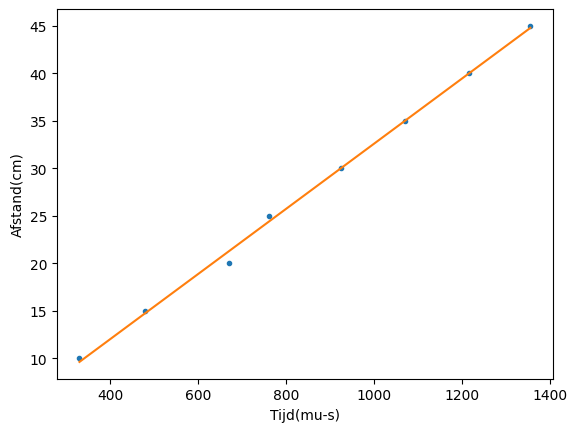

a en b zijn: [ 0.03429911 -1.68425201]


In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

Afstand = np.array([10,15,20,25,30,35,40,45])
Tijd = np.array([330,480,670,761,925,1070,1216,1355])

def func(x,a,b):
    return a*x+b

popt, pcov = curve_fit(func, Tijd, Afstand)

Tijd_test = np.linspace(np.min(Tijd), np.max(Tijd),100)
Af_test = func(Tijd_test, *popt)

plt.figure()
plt.plot(Tijd, Afstand,'.')
plt.plot(Tijd_test, Af_test)
plt.xlabel("Tijd(mu-s)")
plt.ylabel("Afstand(cm)")
plt.show()

print("a en b zijn:",popt)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  40.5
1   0  30   0  20  40.6
2   0  10   0  20  45.1
3  40   0  30   0  41.2
4  30   0  20   0  40.8
5  10   0  20   0  45.0
6  10   0   0  10  45.0


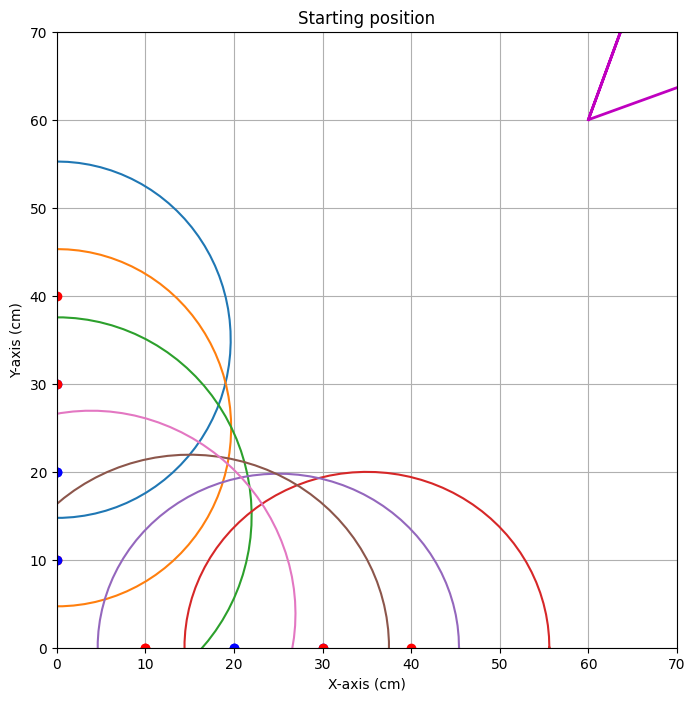


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=106.994


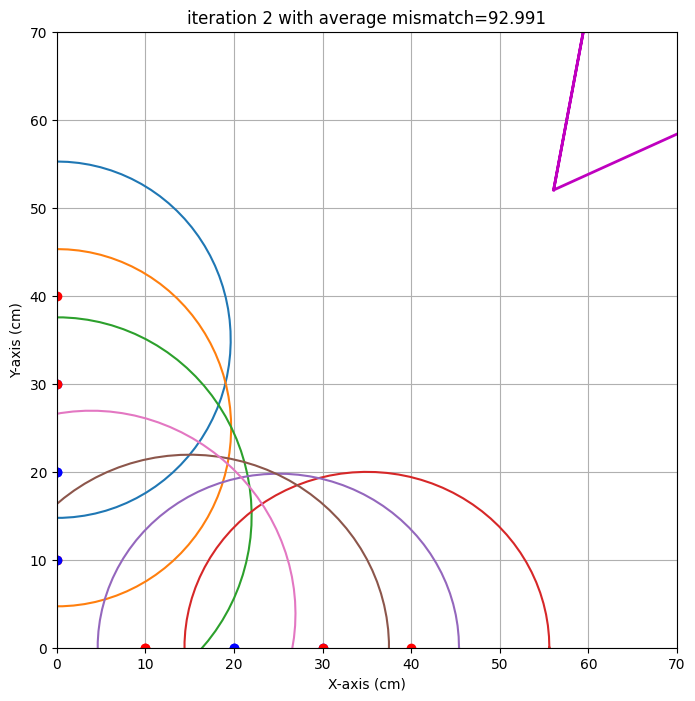

end iteration 2 with average mismatch=92.991


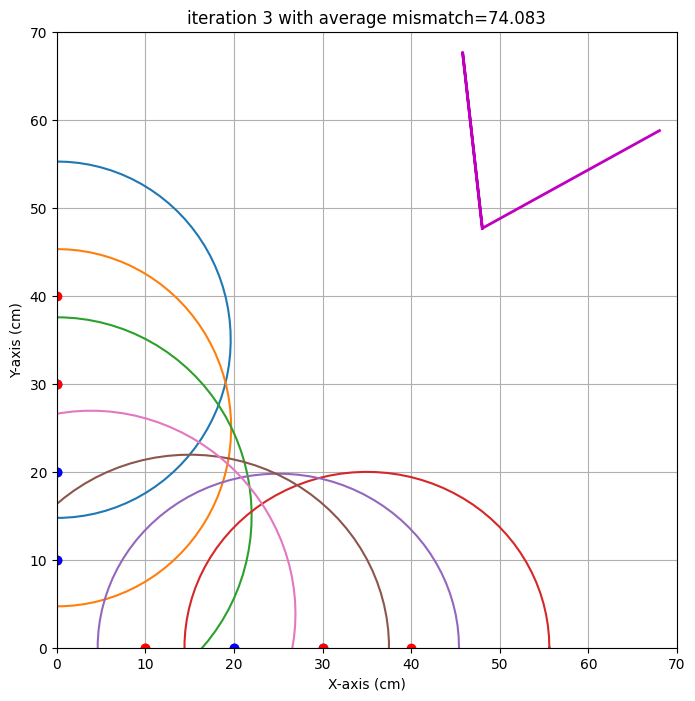

end iteration 3 with average mismatch=74.083


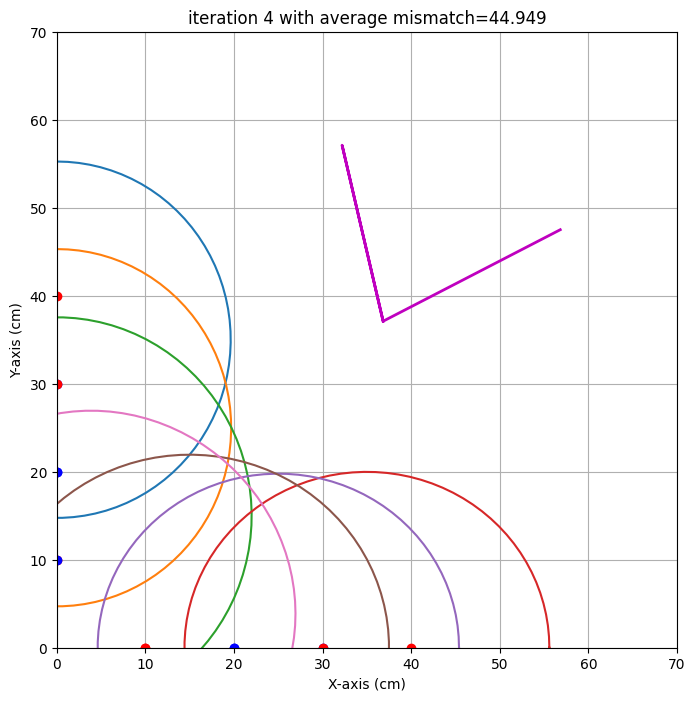

end iteration 4 with average mismatch=44.949


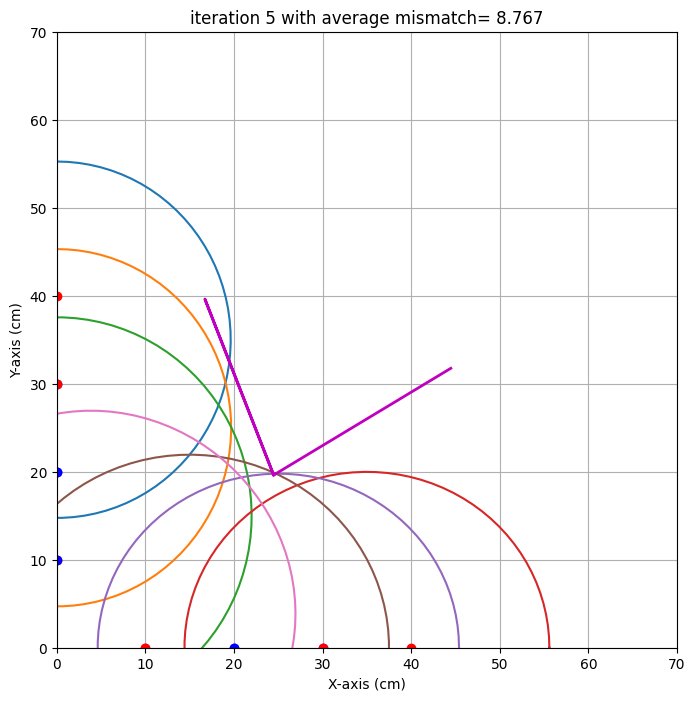

end iteration 5 with average mismatch= 8.767


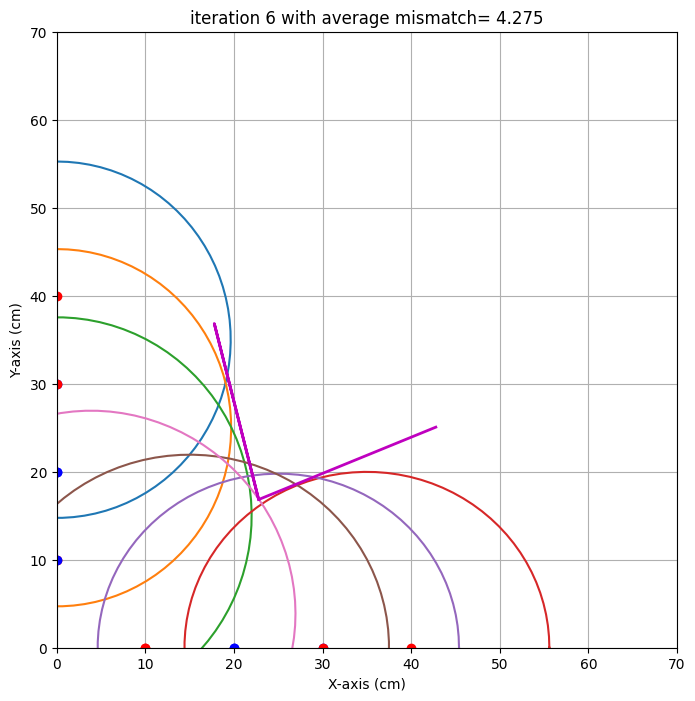

end iteration 6 with average mismatch= 4.275


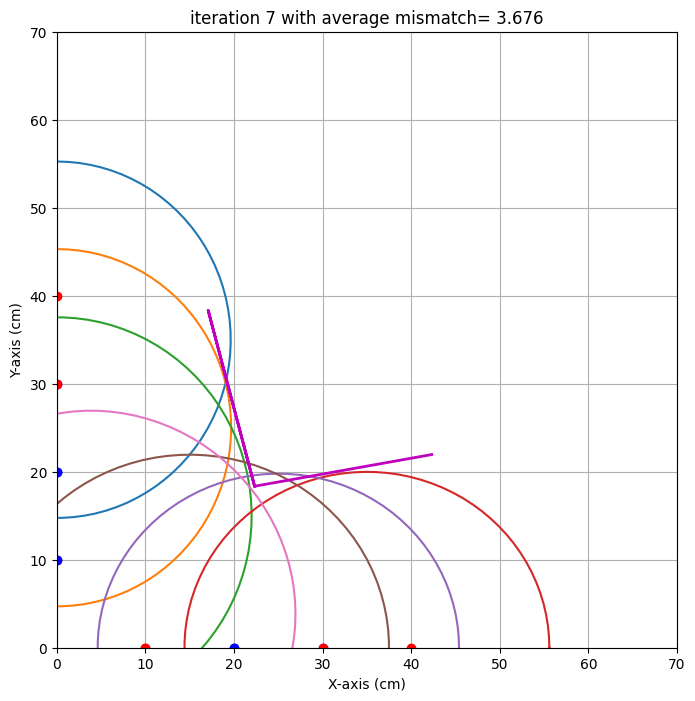

end iteration 7 with average mismatch= 3.676
end iteration 8 with average mismatch= 3.632
end iteration 9 with average mismatch= 3.322


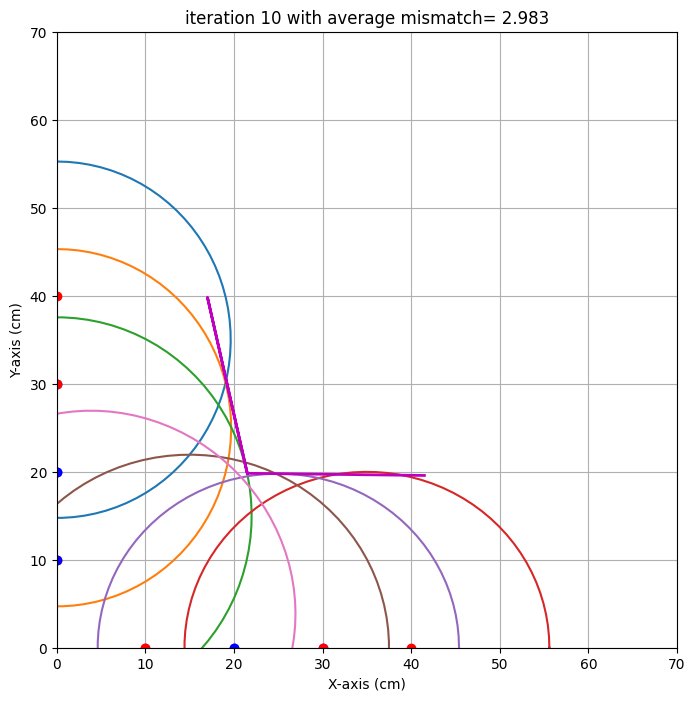

end iteration 10 with average mismatch= 2.983
end iteration 11 with average mismatch= 2.789
end iteration 12 with average mismatch= 2.729
end iteration 13 with average mismatch= 2.716
end iteration 14 with average mismatch= 2.712
end iteration 15 with average mismatch= 2.707
end iteration 16 with average mismatch= 2.700
end iteration 17 with average mismatch= 2.697
end iteration 18 with average mismatch= 2.695
end iteration 19 with average mismatch= 2.695
end iteration 20 with average mismatch= 2.694
end iteration 21 with average mismatch= 2.694
end iteration 22 with average mismatch= 2.694
end iteration 23 with average mismatch= 2.651
end iteration 24 with average mismatch= 2.651
end iteration 25 with average mismatch= 2.651
end iteration 26 with average mismatch= 2.651
end iteration 27 with average mismatch= 2.651
end iteration 28 with average mismatch= 2.651
end iteration 29 with average mismatch= 2.650
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

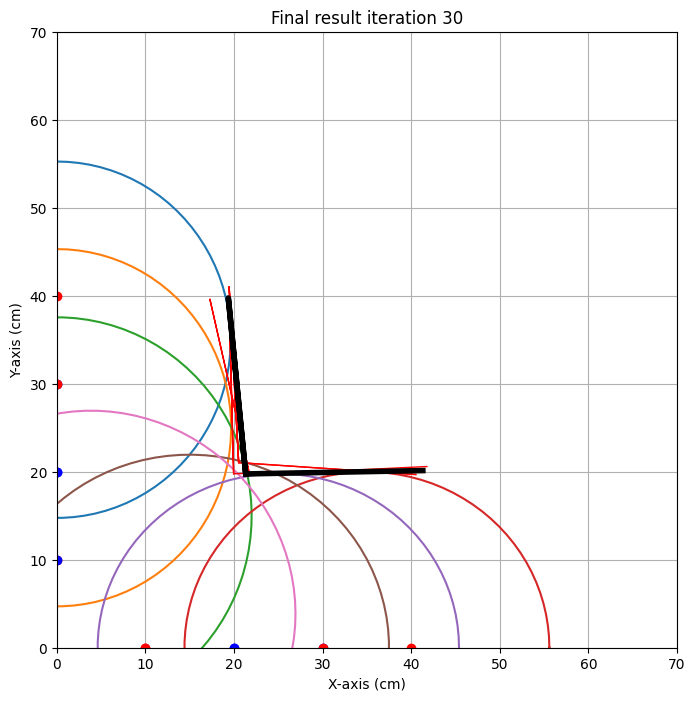

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.6],
    [0,10,0,20,45.1],
    [40,0,30,0,41.2],
    [30,0,20,0,40.8],
    [10,0,20,0,45],
    [10,0,0,10,45]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.3 cm met een standaardafwijking van 1.4 cm 
y0: 19.8 cm met een standaardafwijking van 1.3 cm 
alpha: 1.1 graden met een standaardafwijking van 5.0 graad 
beta: -5.6 graden met een standaardafwijking van 7.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Sriman]

<img src="Alg1.jpeg" width="400">

#### algoritme [Juraj]

<img src="Alg2.jpeg" width="400">

#### algoritme [Carsten]

<img src="Alg3.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,
           'y0':20,
           'alpha' : 10,
           'beta' : 5,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
       'Sriman' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [25,0,40,0,43.58],
    [25,0,35,0,43.39],
    [25,0,30,0,41.60],
    [0,25,0,40,43.80],
    [0,25,0,35,41.38],
    [0,25,0,30,39.90]
    ]),
       'Juraj' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,45,0,45.9],
    [35,0,40,0,43.8],
    [30,0,35,0,42.2],
    [25,0,30,0,40.9],
    [0,40,0,45,41.7],
    [0,35,0,40,40.8],
    [0,30,0,35,40.1],
    [0,25,0,30,39.3]
    ])
      }

## Opdracht 7: Evaluatie.

Sriman
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  25   0  40   0  43.58
1  25   0  35   0  43.39
2  25   0  30   0  41.60
3   0  25   0  40  43.80
4   0  25   0  35  41.38
5   0  25   0  30  39.90


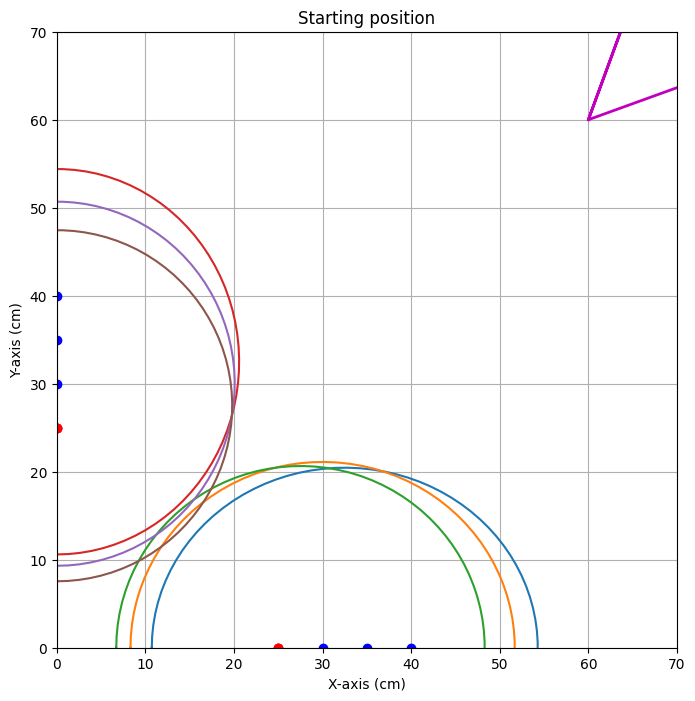


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.505


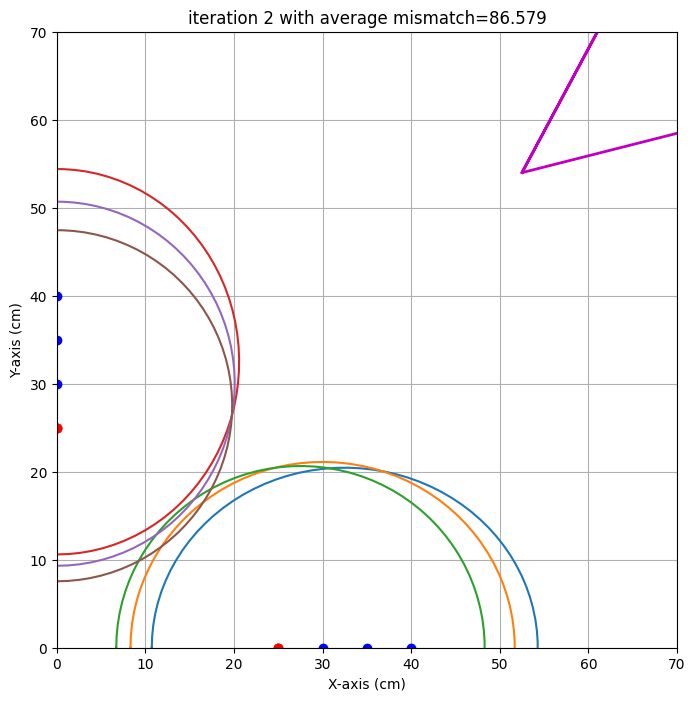

end iteration 2 with average mismatch=86.579


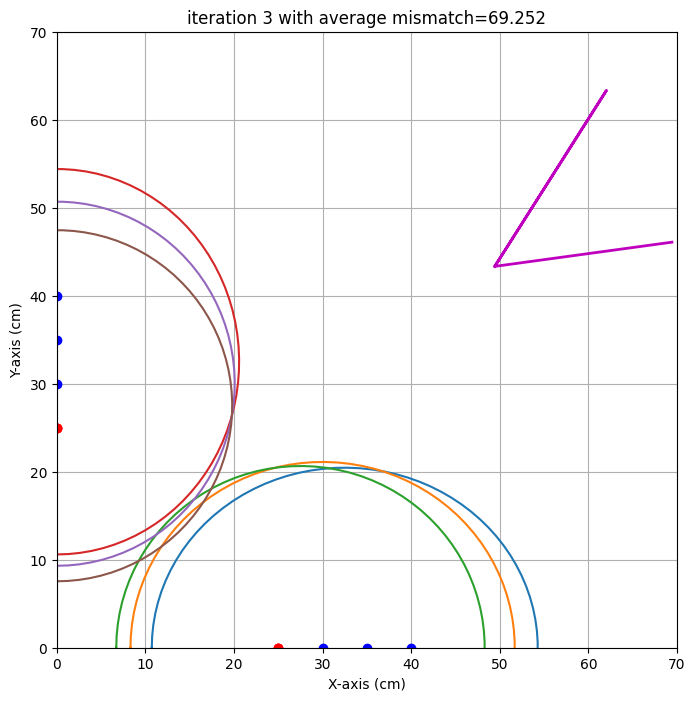

end iteration 3 with average mismatch=69.252


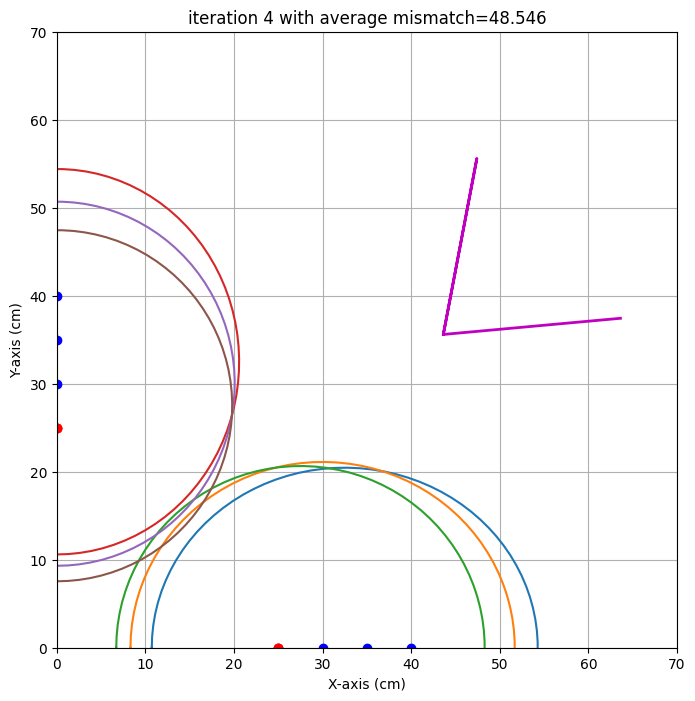

end iteration 4 with average mismatch=48.546


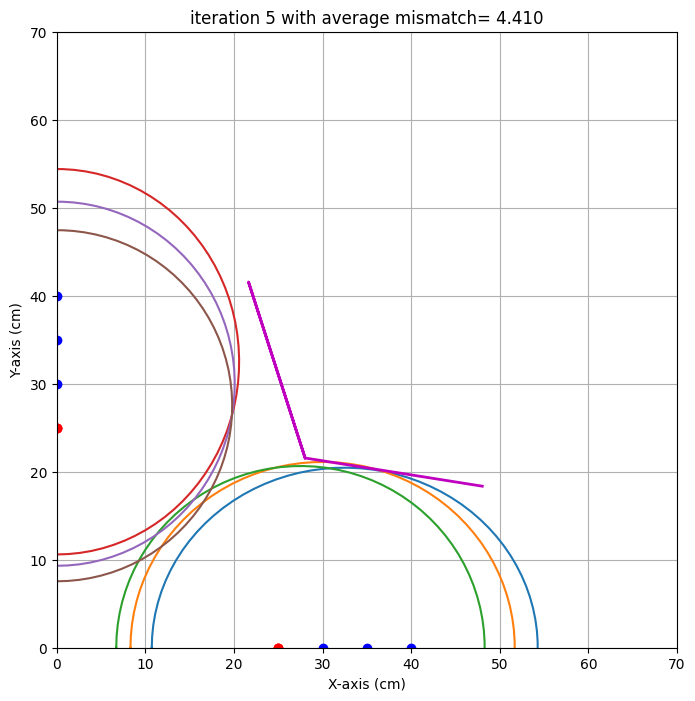

end iteration 5 with average mismatch= 4.410


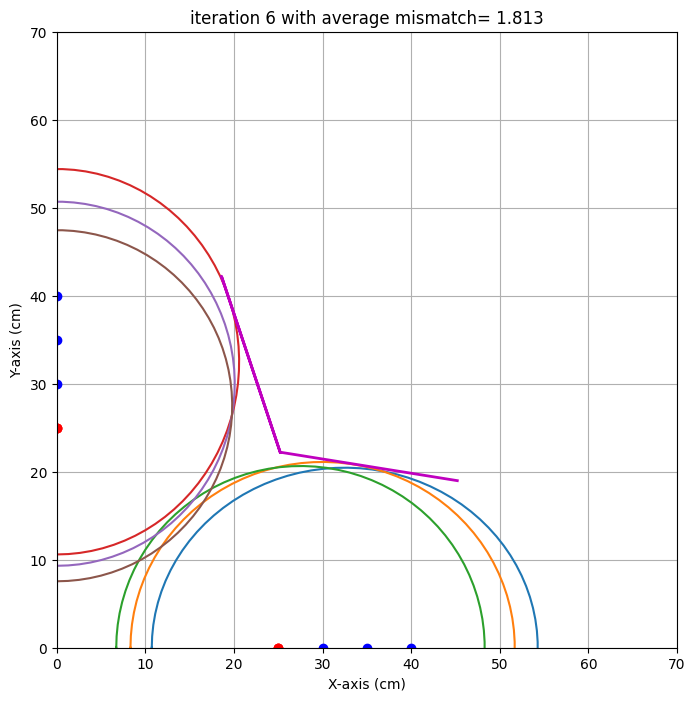

end iteration 6 with average mismatch= 1.813


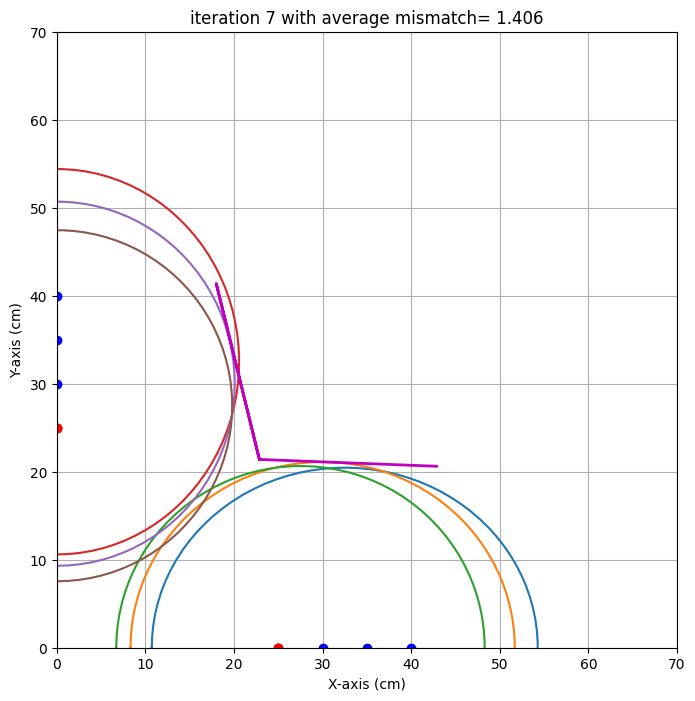

end iteration 7 with average mismatch= 1.406
end iteration 8 with average mismatch= 1.405
end iteration 9 with average mismatch= 1.404
end iteration 10 with average mismatch= 1.378
end iteration 11 with average mismatch= 1.377
end iteration 12 with average mismatch= 1.377
end iteration 13 with average mismatch= 1.377
end iteration 14 with average mismatch= 1.248


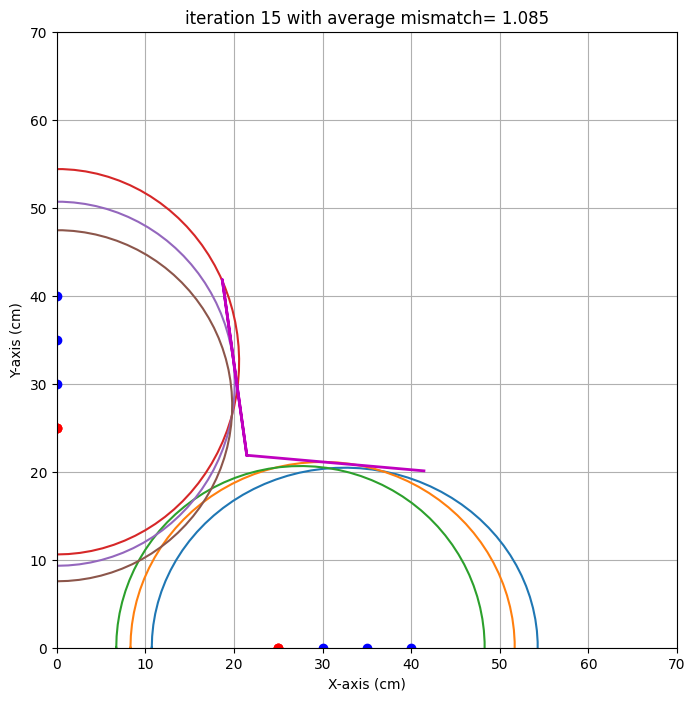

end iteration 15 with average mismatch= 1.085
end iteration 16 with average mismatch= 1.059
end iteration 17 with average mismatch= 1.056
end iteration 18 with average mismatch= 1.055
end iteration 19 with average mismatch= 1.055
end iteration 20 with average mismatch= 1.055
end iteration 21 with average mismatch= 1.055
end iteration 22 with average mismatch= 1.055
end iteration 23 with average mismatch= 1.055
end iteration 24 with average mismatch= 1.055
end iteration 25 with average mismatch= 1.055
end iteration 26 with average mismatch= 1.055
end iteration 27 with average mismatch= 1.055
end iteration 28 with average mismatch= 1.034
end iteration 29 with average mismatch= 1.006
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


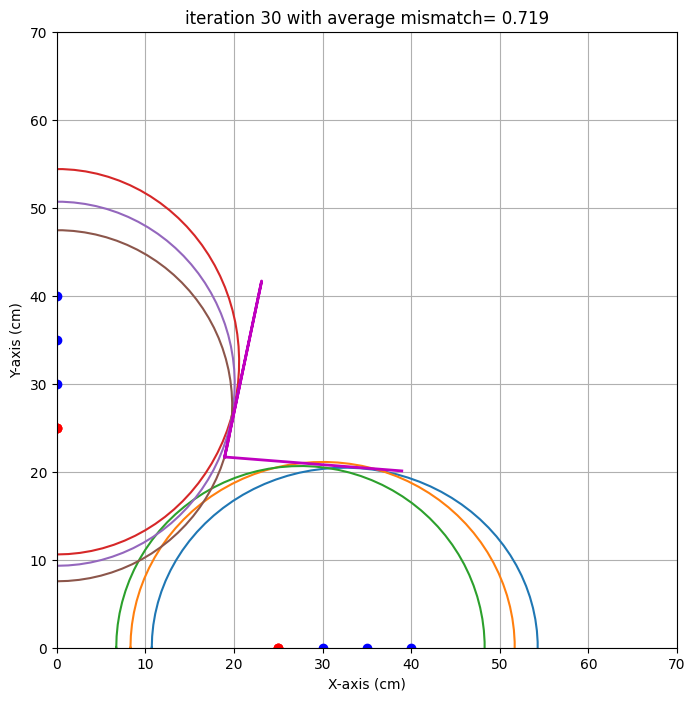

end iteration 30 with average mismatch= 0.719
###############################################################################
end of iteration  30
Best alpha=  -4.53 with uncertainty=   2.75
Best beta =  11.80 with uncertainty=   8.98
Best x0   =  18.94 with uncertainty=   0.97
Best y0   =  21.67 with uncertainty=   1.05
###############################################################################


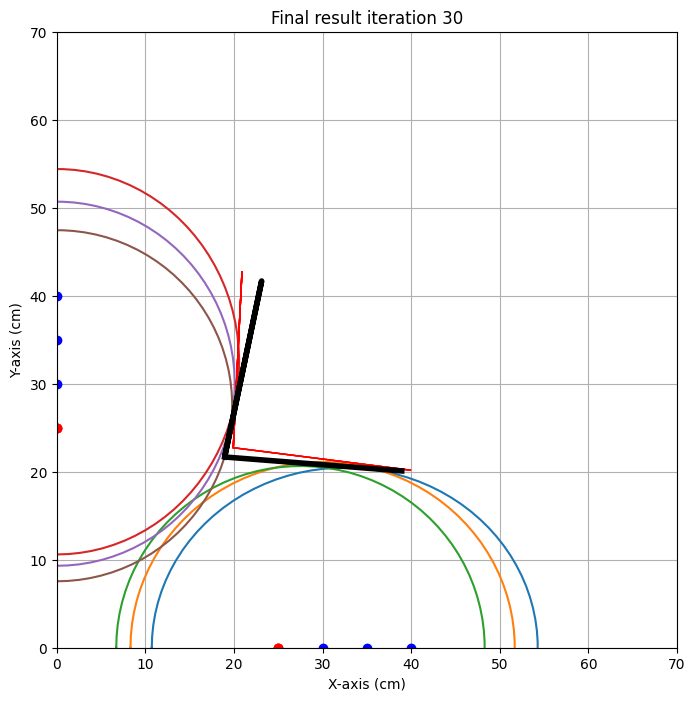

{'alpha': np.float64(-4.525689199682609), 'alpha_eps': np.float64(2.7511380551107445), 'beta': np.float64(11.799055657609635), 'beta_eps': np.float64(8.979423912871288), 'x0': np.float64(18.938280172129158), 'x0_eps': np.float64(0.9721230171614117), 'y0': np.float64(21.6747700824493), 'y0_eps': np.float64(1.0539558122584154)}
Juraj
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  45   0  45.9
1  35   0  40   0  43.8
2  30   0  35   0  42.2
3  25   0  30   0  40.9
4   0  40   0  45  41.7
5   0  35   0  40  40.8
6   0  30   0  35  40.1
7   0  25   0  30  39.3


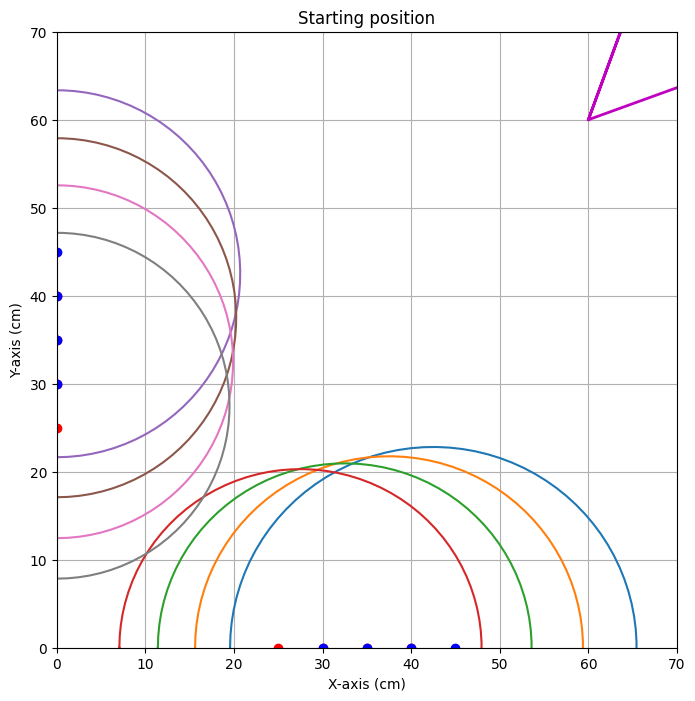


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.666


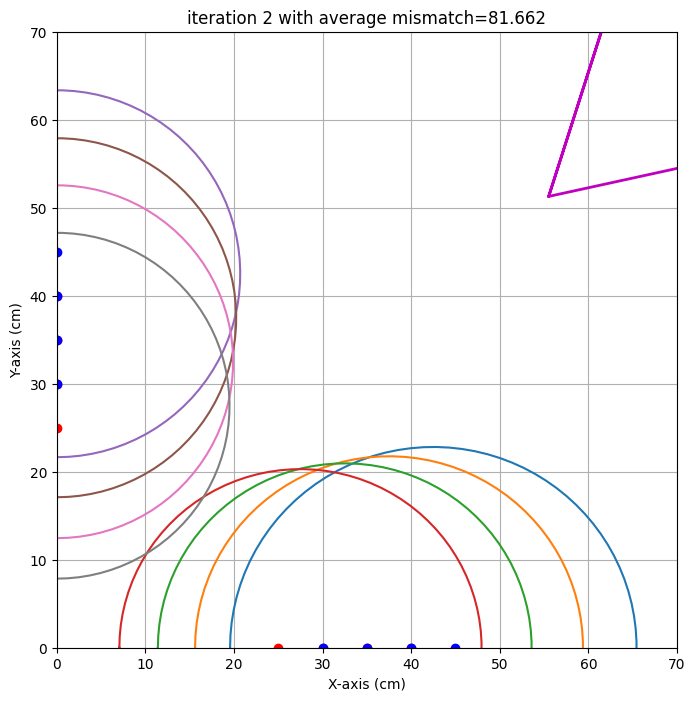

end iteration 2 with average mismatch=81.662


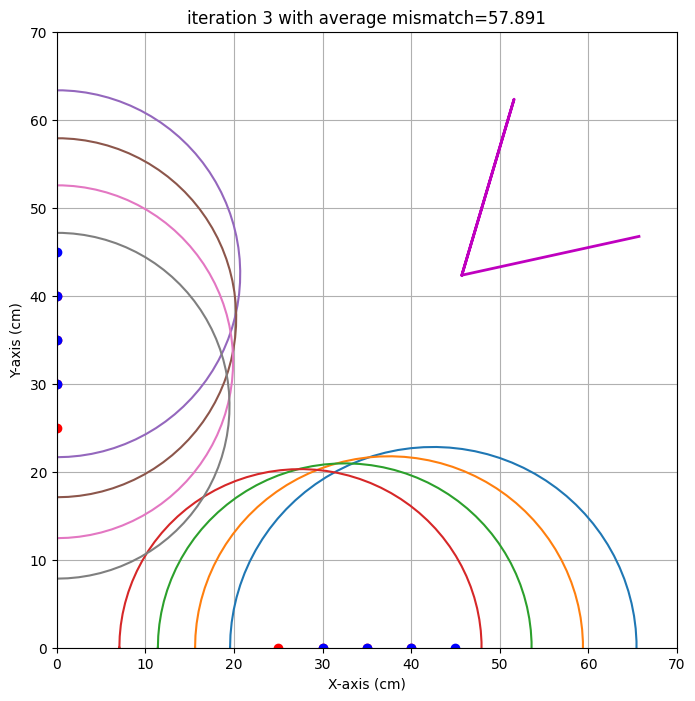

end iteration 3 with average mismatch=57.891


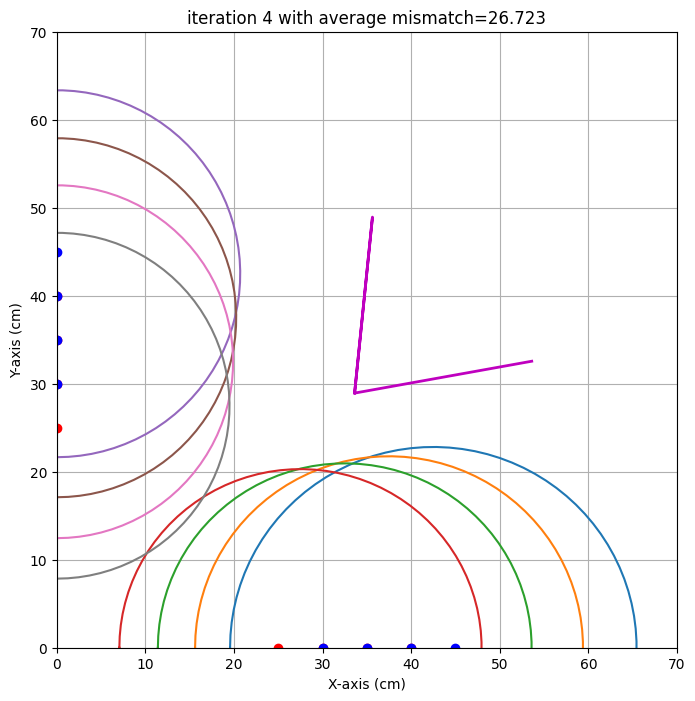

end iteration 4 with average mismatch=26.723


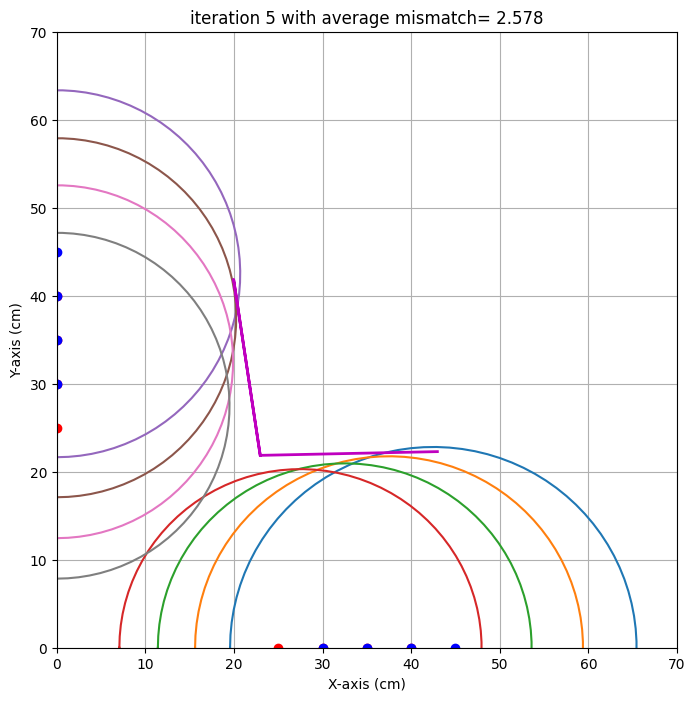

end iteration 5 with average mismatch= 2.578


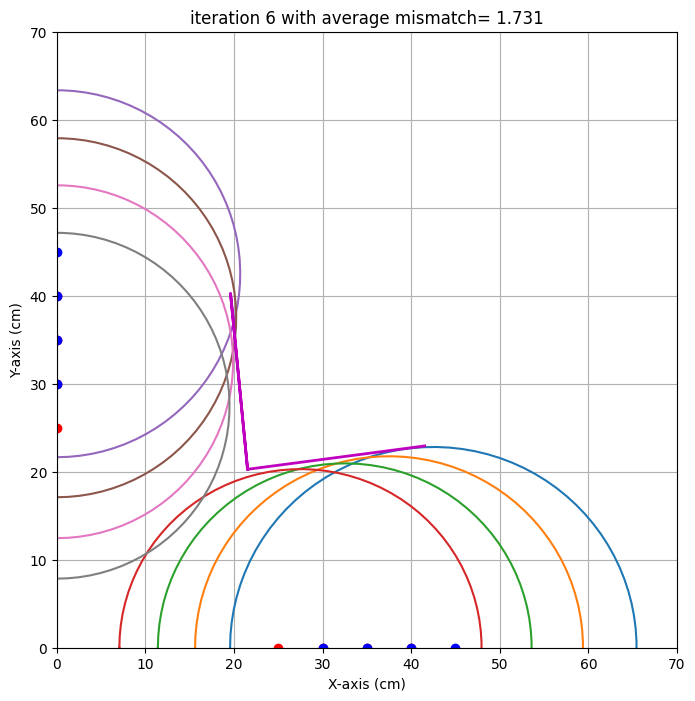

end iteration 6 with average mismatch= 1.731


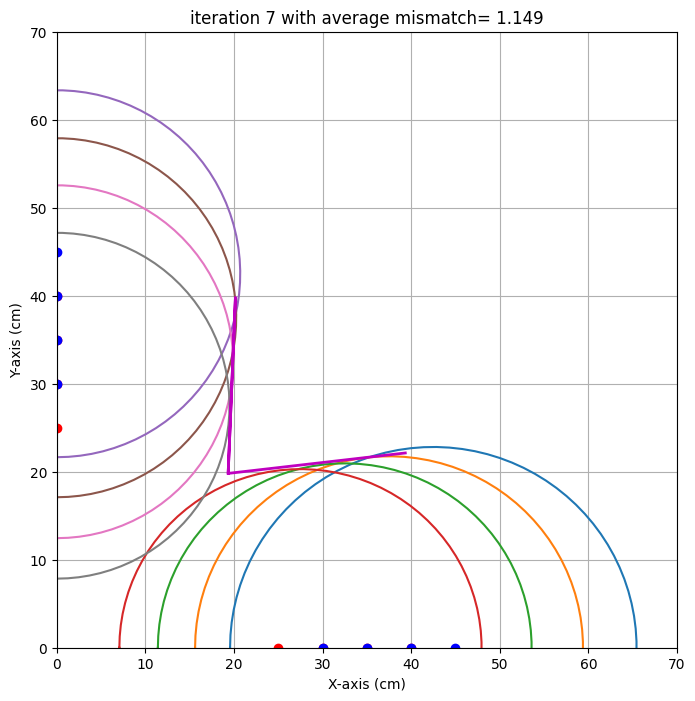

end iteration 7 with average mismatch= 1.149


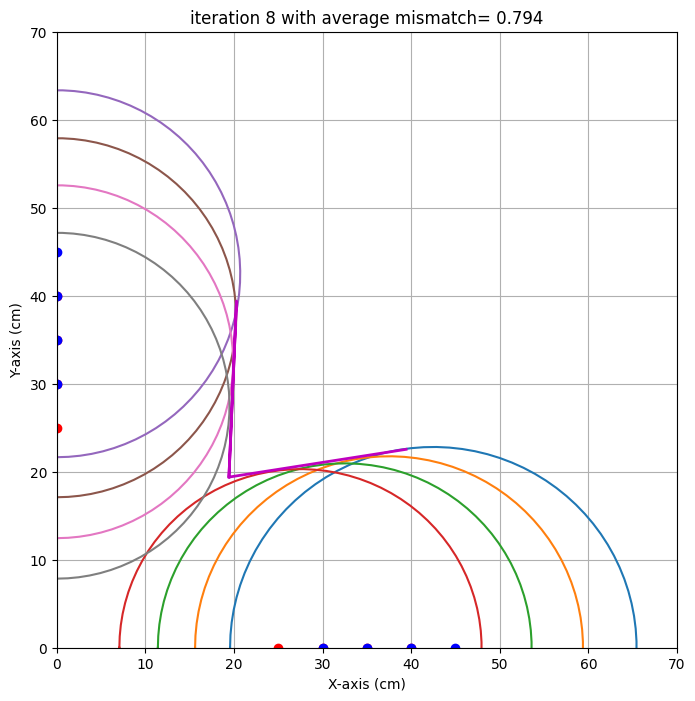

end iteration 8 with average mismatch= 0.794


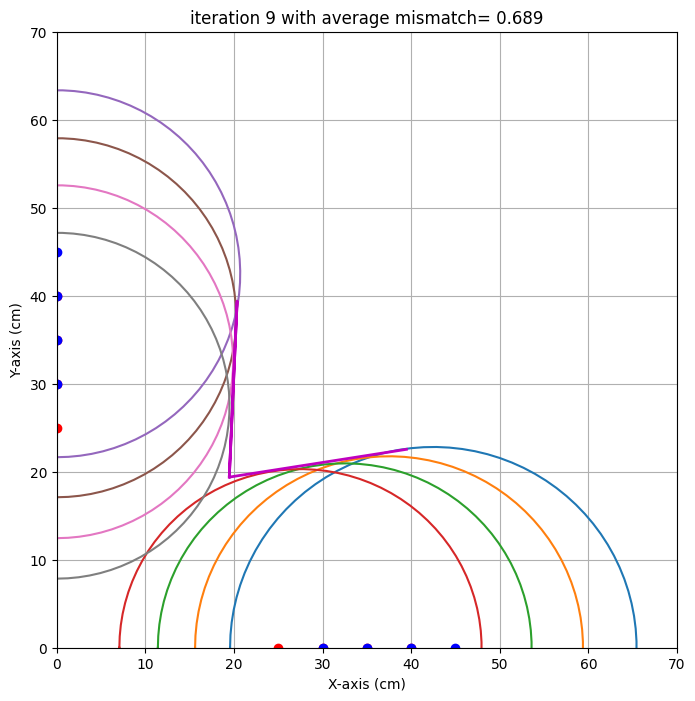

end iteration 9 with average mismatch= 0.689
end iteration 10 with average mismatch= 0.687
end iteration 11 with average mismatch= 0.686
end iteration 12 with average mismatch= 0.686
end iteration 13 with average mismatch= 0.686
end iteration 14 with average mismatch= 0.686
end iteration 15 with average mismatch= 0.686
end iteration 16 with average mismatch= 0.686
end iteration 17 with average mismatch= 0.686
end iteration 18 with average mismatch= 0.686
end iteration 19 with average mismatch= 0.686
end iteration 20 with average mismatch= 0.686
end iteration 21 with average mismatch= 0.686
end iteration 22 with average mismatch= 0.686
end iteration 23 with average mismatch= 0.686
end iteration 24 with average mismatch= 0.686
end iteration 25 with average mismatch= 0.686
end iteration 26 with average mismatch= 0.674
end iteration 27 with average mismatch= 0.674
end iteration 28 with average mismatch= 0.674
end iteration 29 with average mismatch= 0.674
Last iteration, also determine unce

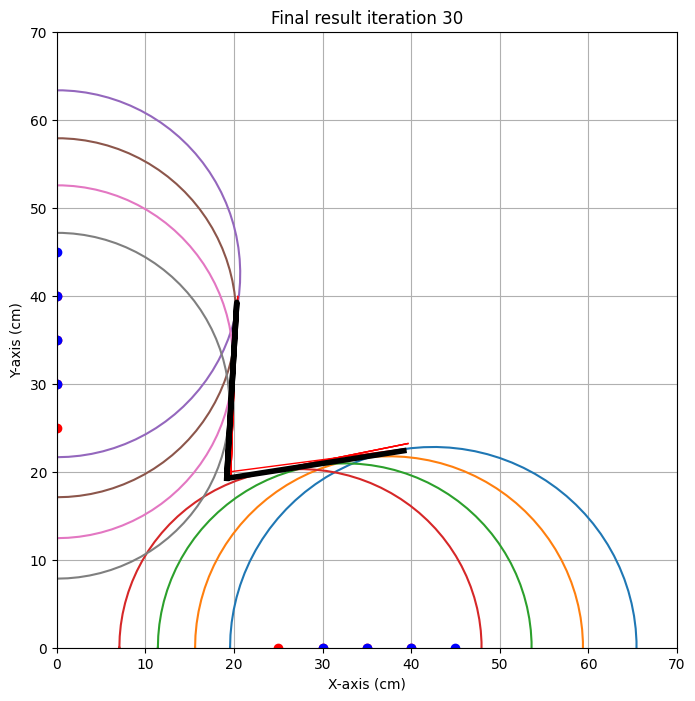

{'alpha': np.float64(8.912522525905246), 'alpha_eps': np.float64(2.547886225837365), 'beta': np.float64(3.2563883831776743), 'beta_eps': np.float64(1.3255461891435978), 'x0': np.float64(19.171614353502427), 'x0_eps': np.float64(0.4503333036793258), 'y0': np.float64(19.24922833917966), 'y0_eps': np.float64(0.702438418379387)}
Carsten


KeyError: 'Carsten'

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Sriman 
x0 target is : 20.0. Gevonden waarde: 19.1 cm met een standaardafwijking van 0.0 cm 
y0 target is : 20.0. Gevonden waarde: 22.4 cm met een standaardafwijking van 0.5 cm 
alpha target is : 10.0. Gevonden waarde: -6.3 graden met een standaardafwijking van 3.6 graad 
beta target is : 5.0. Gevonden waarde: 10.9 graden met een standaardafwijking van 2.1 graad 

Juraj 
x0 target is : 20.0. Gevonden waarde: 19.2 cm met een standaardafwijking van 0.9 cm 
y0 target is : 20.0. Gevonden waarde: 19.4 cm met een standaardafwijking van 0.2 cm 
alpha target is : 10.0. Gevonden waarde: 8.9 graden met een standaardafwijking van 2.1 graad 
beta target is : 5.0. Gevonden waarde: 3.4 graden met een standaardafwijking van 2.8 graad 



KeyError: 'Carsten'

## Opdracht 8: Iteratie1+16.29.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](It_fin.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
     xs    ys    xr    yr   R
0  32.5   0.0  37.5   0.0  97
1  42.5   0.0  47.5   0.0  88
2  52.5   0.0  57.5   0.0  88
3   0.0  32.5   0.0  37.5  94
4   0.0  42.5   0.0  47.5  93
5   0.0  52.5   0.0  57.5  89


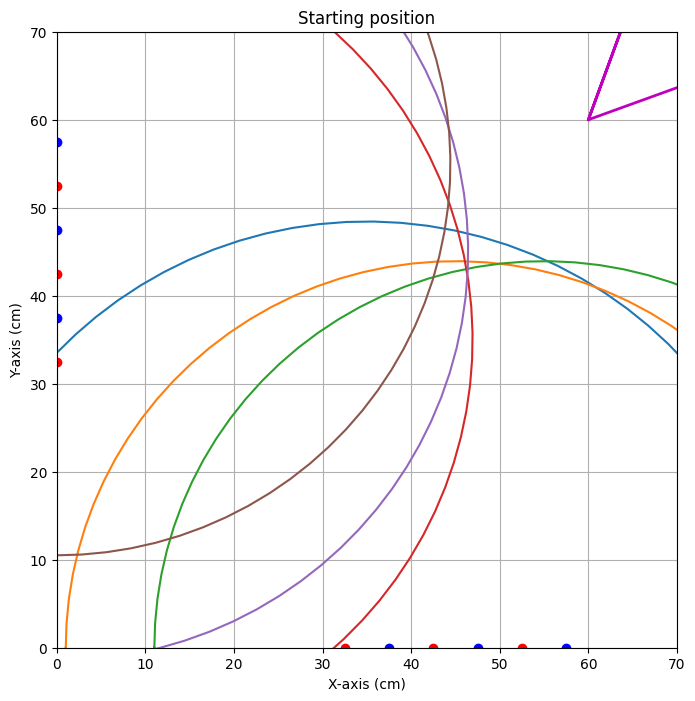


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.738


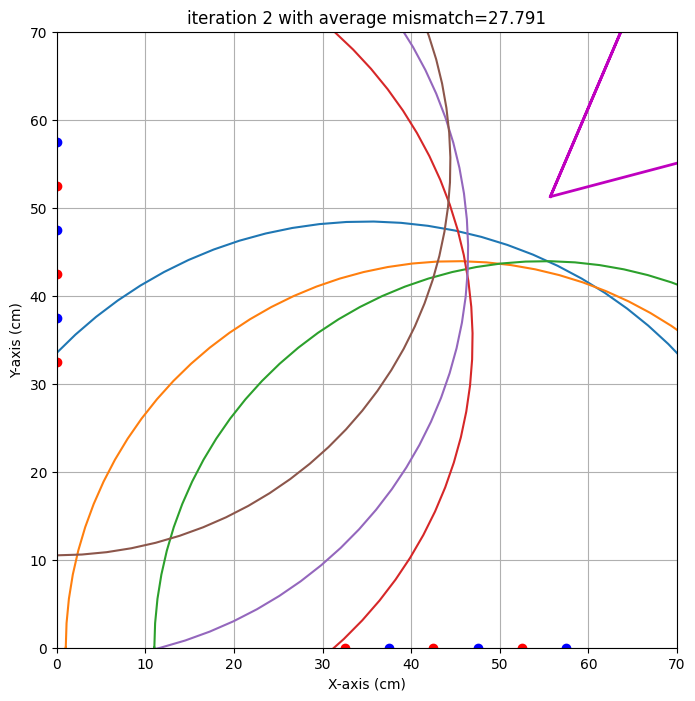

end iteration 2 with average mismatch=27.791


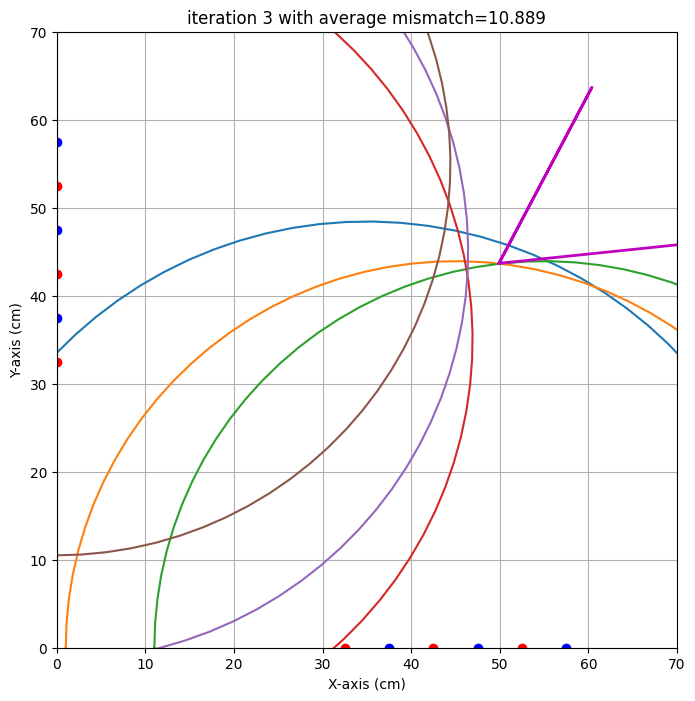

end iteration 3 with average mismatch=10.889


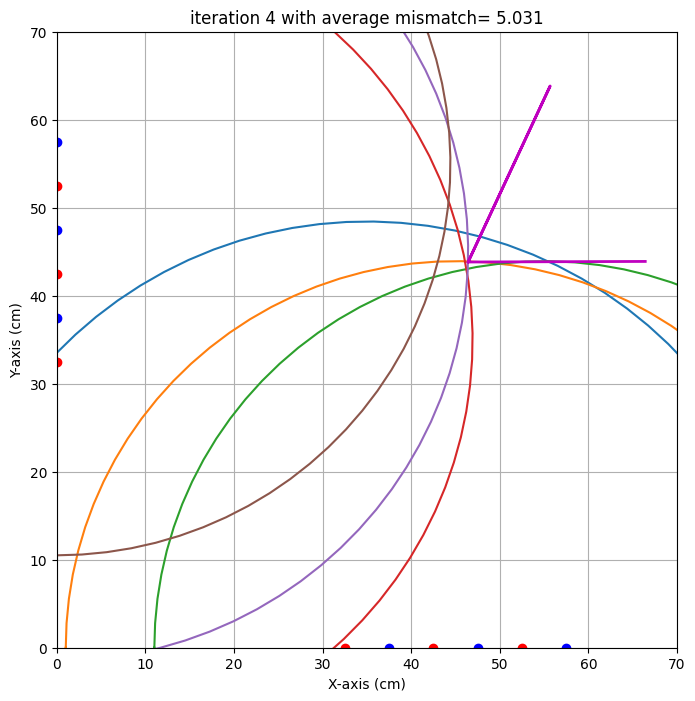

end iteration 4 with average mismatch= 5.031


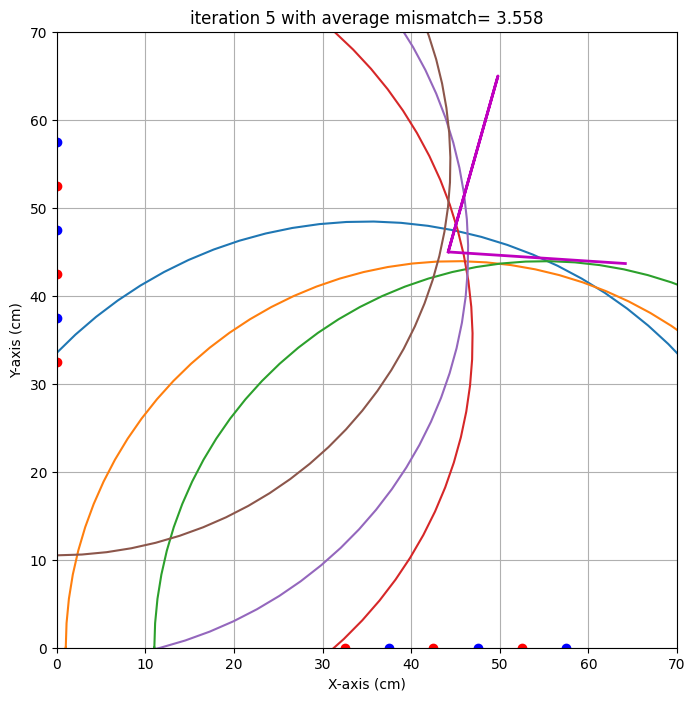

end iteration 5 with average mismatch= 3.558
end iteration 6 with average mismatch= 3.371


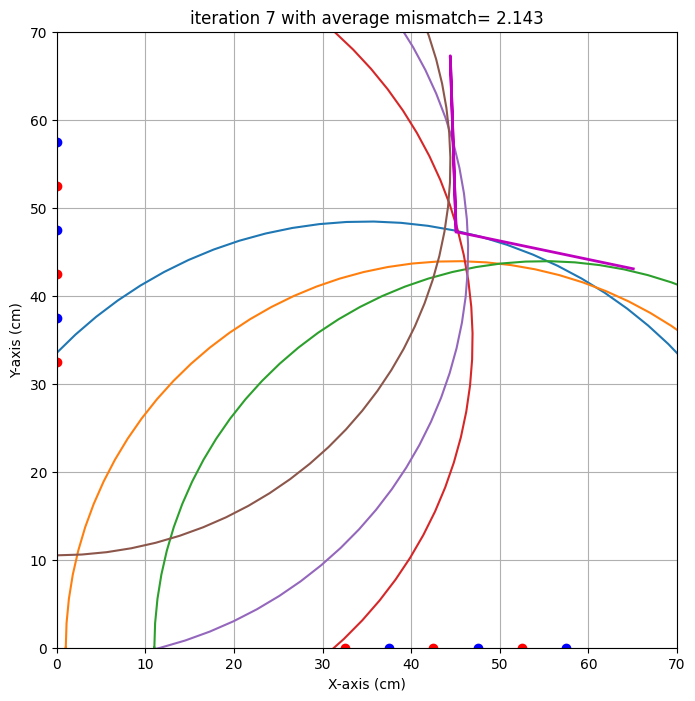

end iteration 7 with average mismatch= 2.143


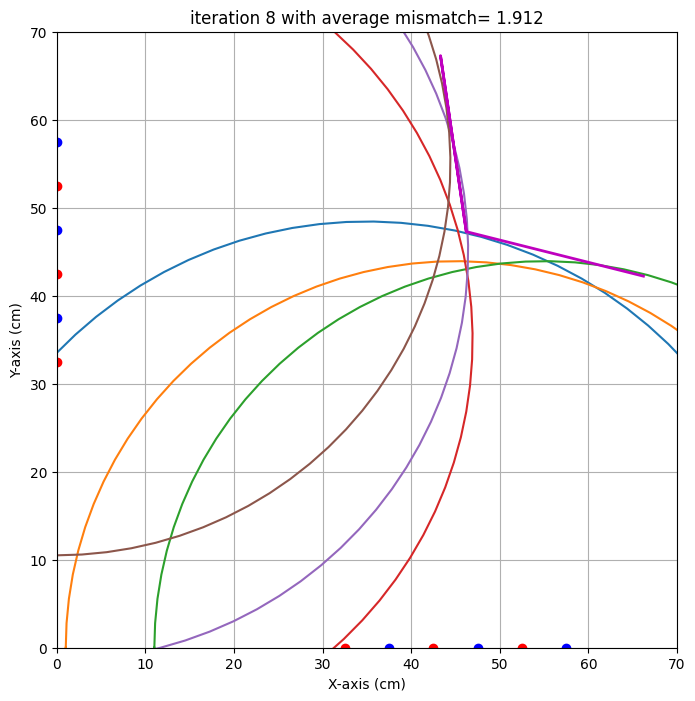

end iteration 8 with average mismatch= 1.912
end iteration 9 with average mismatch= 1.813
end iteration 10 with average mismatch= 1.811
end iteration 11 with average mismatch= 1.811
end iteration 12 with average mismatch= 1.811
end iteration 13 with average mismatch= 1.811
end iteration 14 with average mismatch= 1.810
end iteration 15 with average mismatch= 1.810
end iteration 16 with average mismatch= 1.807
end iteration 17 with average mismatch= 1.788
end iteration 18 with average mismatch= 1.754
end iteration 19 with average mismatch= 1.749
end iteration 20 with average mismatch= 1.749
end iteration 21 with average mismatch= 1.748
end iteration 22 with average mismatch= 1.748
end iteration 23 with average mismatch= 1.748
end iteration 24 with average mismatch= 1.748
end iteration 25 with average mismatch= 1.748
end iteration 26 with average mismatch= 1.748
end iteration 27 with average mismatch= 1.748
end iteration 28 with average mismatch= 1.748
end iteration 29 with average mismat

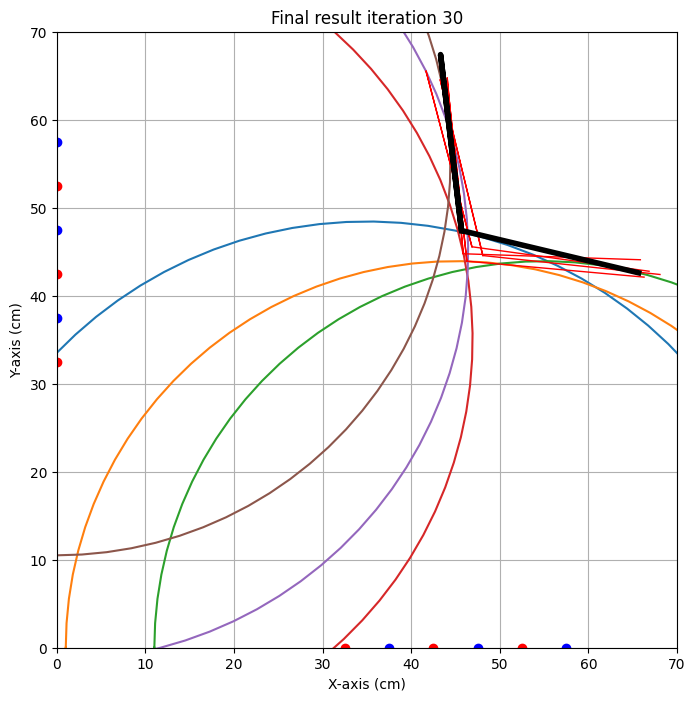

{'alpha': np.float64(-13.49420471363451), 'alpha_eps': np.float64(11.544880089955686), 'beta': np.float64(-6.743407920191237), 'beta_eps': np.float64(7.803951347064534), 'x0': np.float64(45.67995031514378), 'x0_eps': np.float64(2.4094926725627275), 'y0': np.float64(47.402355264171035), 'y0_eps': np.float64(3.4725695561010426)}
locatie 2
Running the imaging algorithm with the following data:
     xs    ys    xr    yr   R
0  32.5   0.0  37.5   0.0  56
1  42.5   0.0  47.5   0.0  59
2  52.5   0.0  57.5   0.0  63
3   0.0  32.5   0.0  37.5  58
4   0.0  42.5   0.0  47.5  61
5   0.0  52.5   0.0  57.5  65
6   0.0  22.5   0.0  27.5  61


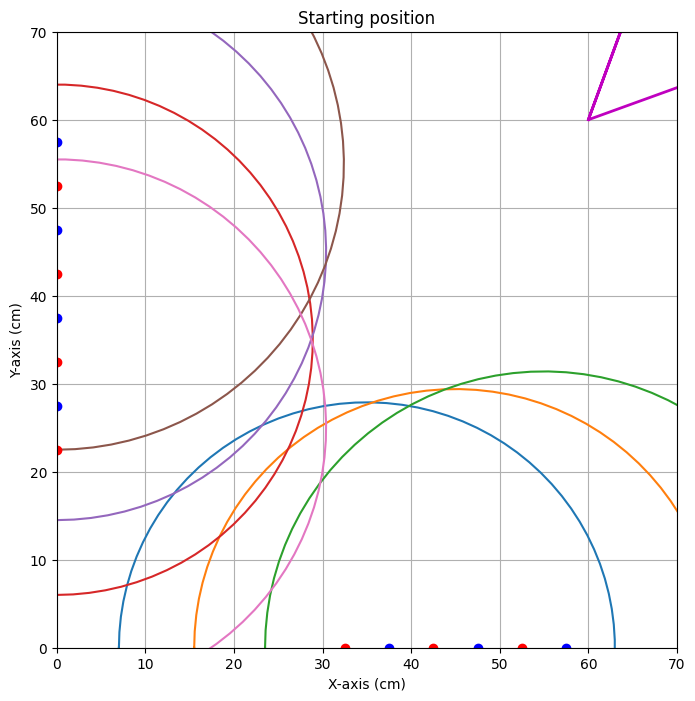


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.779


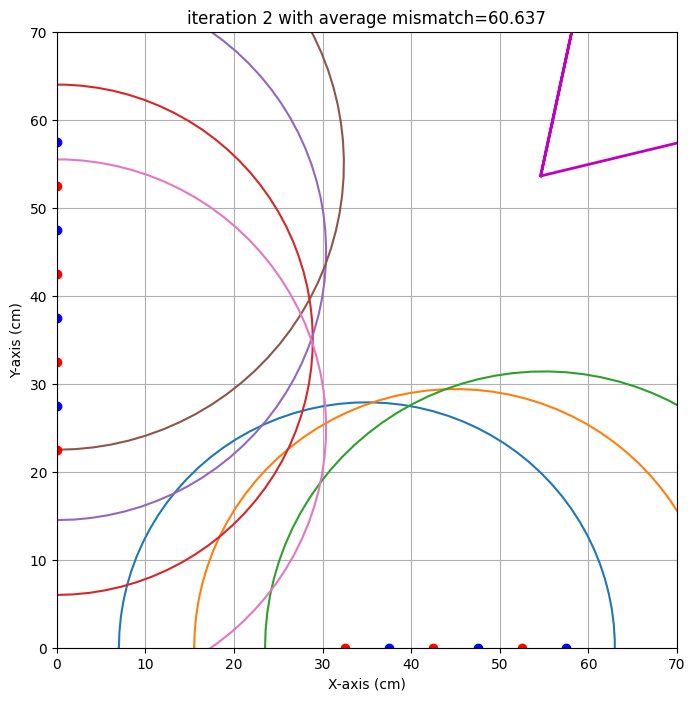

end iteration 2 with average mismatch=60.637


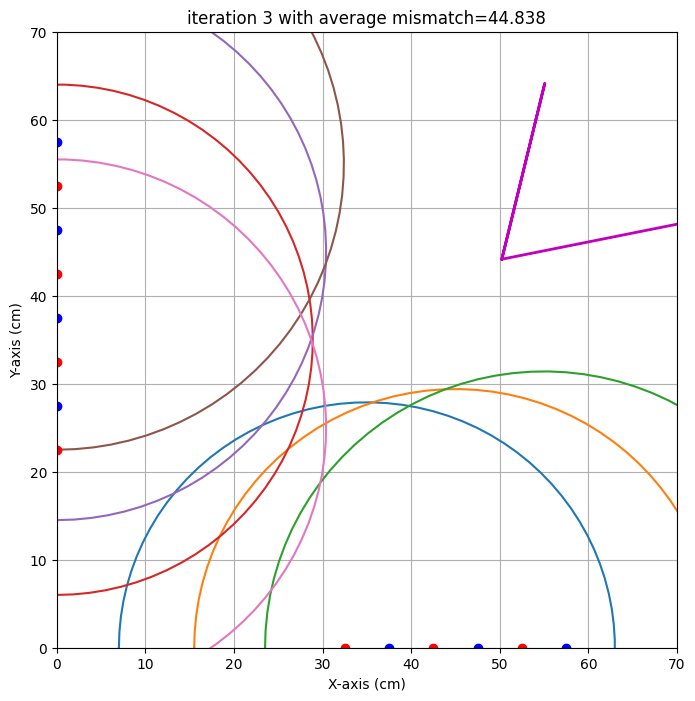

end iteration 3 with average mismatch=44.838


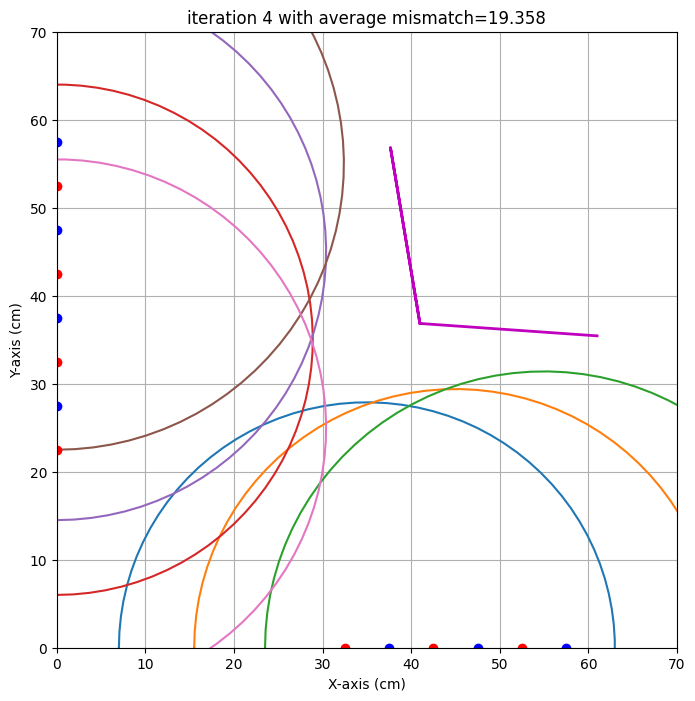

end iteration 4 with average mismatch=19.358


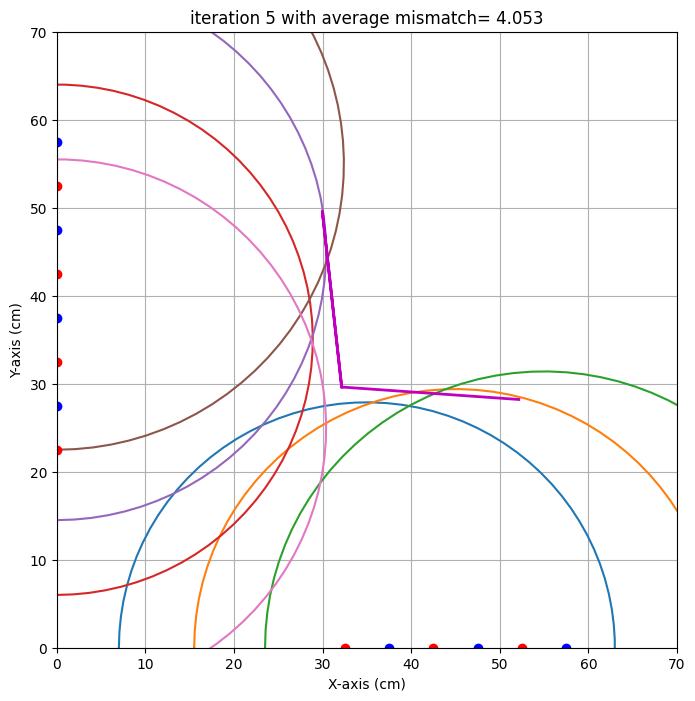

end iteration 5 with average mismatch= 4.053


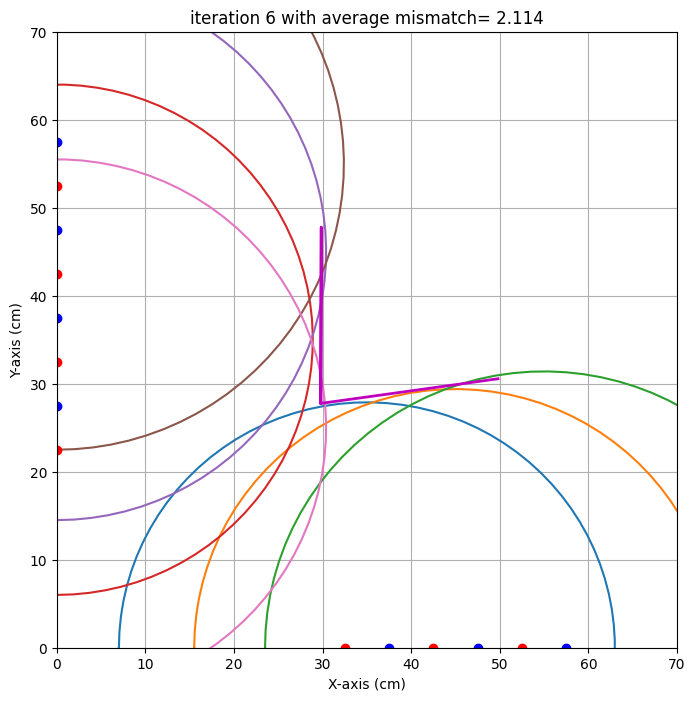

end iteration 6 with average mismatch= 2.114


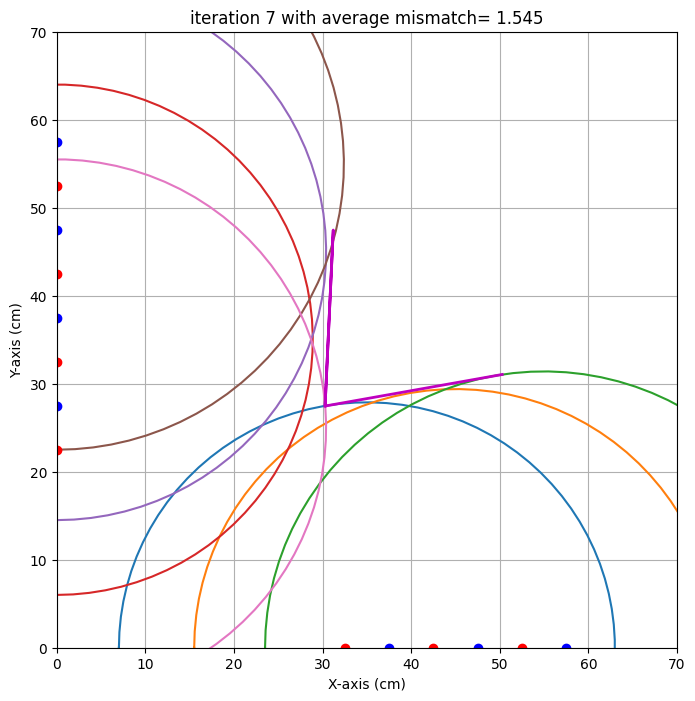

end iteration 7 with average mismatch= 1.545
end iteration 8 with average mismatch= 1.544
end iteration 9 with average mismatch= 1.544
end iteration 10 with average mismatch= 1.491
end iteration 11 with average mismatch= 1.491
end iteration 12 with average mismatch= 1.491
end iteration 13 with average mismatch= 1.491
end iteration 14 with average mismatch= 1.491
end iteration 15 with average mismatch= 1.491
end iteration 16 with average mismatch= 1.491
end iteration 17 with average mismatch= 1.491
end iteration 18 with average mismatch= 1.491
end iteration 19 with average mismatch= 1.491
end iteration 20 with average mismatch= 1.491
end iteration 21 with average mismatch= 1.491
end iteration 22 with average mismatch= 1.491
end iteration 23 with average mismatch= 1.491
end iteration 24 with average mismatch= 1.491
end iteration 25 with average mismatch= 1.491
end iteration 26 with average mismatch= 1.473
end iteration 27 with average mismatch= 1.404
end iteration 28 with average mismatc

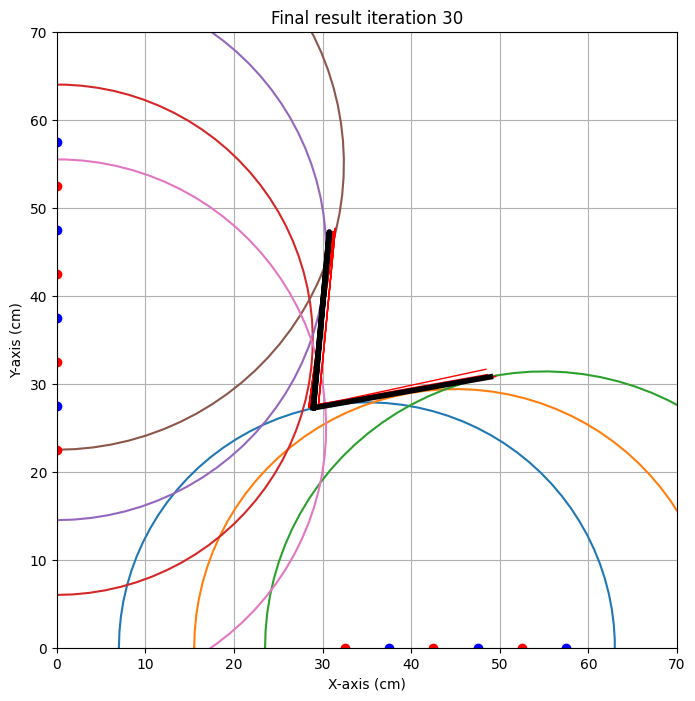

{'alpha': np.float64(10.011455257521083), 'alpha_eps': np.float64(2.1744177160889446), 'beta': np.float64(5.172387226935482), 'beta_eps': np.float64(2.7768174634865117), 'x0': np.float64(28.947317492666453), 'x0_eps': np.float64(0.5923429264756166), 'y0': np.float64(27.250772578834344), 'y0_eps': np.float64(0.41588581597230245)}
locatie 1 
x0 target is : 44.0. Gevonden waarde: 45.7 cm met een standaardafwijking van 2.4 cm 
y0 target is : 43.8. Gevonden waarde: 47.4 cm met een standaardafwijking van 3.5 cm 
alpha target is : 10.0. Gevonden waarde: -13.5 graden met een standaardafwijking van 11.5 graad 
beta target is : 15.0. Gevonden waarde: -6.7 graden met een standaardafwijking van 7.8 graad 

locatie 2 
x0 target is : 28.4. Gevonden waarde: 28.9 cm met een standaardafwijking van 0.6 cm 
y0 target is : 28.6. Gevonden waarde: 27.3 cm met een standaardafwijking van 0.4 cm 
alpha target is : 10.0. Gevonden waarde: 10.0 graden met een standaardafwijking van 2.2 graad 
beta target is : 10.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':44,
                    'y0':43.8,
                    'alpha':10,
                    'beta' :15},
           'locatie 2':{'x0':28.4,
                    'y0':28.6,
                    'alpha' : 10,
                    'beta' : 10
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [32.5,0,37.5,0,97],
    [42.5,0,47.5,0,88],
    [52.5,0,57.5,0,88],
    [62.5,0,67.5,0,91],
    [0,32.5,0,37.5,94],
    [0,42.5,0,47.5,93],
    [0,52.5,0,57.5,89],
    [0,62.5,0,67.5,93]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [32.5,0,37.5,0,56],
    [42.5,0,47.5,0,59],
    [52.5,0,57.5,0,63],
    [0,32.5,0,37.5,58],
    [0,42.5,0,47.5,61],
    [0,52.5,0,57.5,65],
    [0,22.5,0,27.5,61]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")